676
839
95868


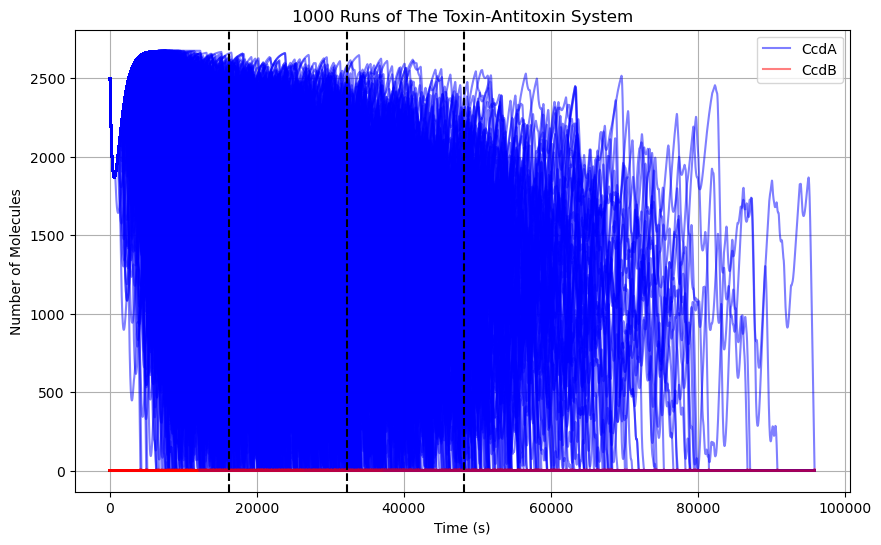

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import statistics as st

data = {}
times = {}

# Load all data files into the dictionary
for n in range(999):
    data[n] = np.load(f'../outputs/sim_{n}.npz')
    times[n] = data[n]['times']

# Find the maximum length of all time arrays
max_len = max(len(data[n]['times']) for n in range(999))

# Preallocate arrays filled with zeros
CcdA_all = np.zeros((999, max_len))
CcdB_all = np.zeros((999, max_len))
t_all    = np.zeros((999, max_len))

first_pass = [times[z][-1] for z in range(999)]

# Compute average
average = sum(first_pass) / len(first_pass)

std = st.stdev([float(x) for x in first_pass])

# Fill each run up to its own length
for n in range(999):
    length = len(data[n]['times'])
    t_all[n, :length] = data[n]['times']
    CcdA_all[n, :length] = data[n]['A']
    CcdB_all[n, :length] = data[n]['B']
    # Remaining entries stay zero
    
w=0
y=0
    
for t in first_pass:
    if t>average-std and t<average+std:
        w=w+1

for t in first_pass:
    if t<average+std:
        y=y+1

print(w)
print(y)

# Use the maximum common time grid (from the longest sim)
t_common = np.max(t_all, axis=0)

# Plot
plt.figure(figsize=(10,6))

for n in range(999):
    if n == 0:
        plt.plot(t_common, CcdA_all[n], color="blue", alpha=0.5, label="CcdA")
        plt.plot(t_common, CcdB_all[n], color="red", alpha=0.5, label="CcdB")
    else:
        plt.plot(t_common, CcdA_all[n], color="blue", alpha=0.5)
        plt.plot(t_common, CcdB_all[n], color="red", alpha=0.5)

plt.xlabel("Time (s)")
plt.ylabel("Number of Molecules")
plt.title("1000 Runs of The Toxin-Antitoxin System")

for i in (average, average+std, average-std):
    plt.axvline(x=i, color="black", linestyle="--")

plt.legend()
plt.grid(True)
plt.savefig("final_graphs\multi_graph.png")

print(max_len)   


